# B6 – Robustness Check: Bilateral RER → Multilateral REER

**Mục tiêu:** Thay `ln_RER_pos` / `ln_RER_neg` (bilateral VND/USD RER) bằng  
`ln_REER_pos` / `ln_REER_neg` (multilateral REER, base 2007M12=100), chạy lại  
2 models EX và IM, so sánh với baseline B4.

**Nguồn REER:** `../data/raw/` – cột `REER (2007M12 = 100)`.

> Nếu long-run coefficients nhất quán về dấu & ý nghĩa → findings bền vững.

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from statsmodels.tsa.ardl import ARDL
from statsmodels.regression.linear_model import OLS
from scipy import stats as scipy_stats

print('Libraries loaded ✓')

Libraries loaded ✓


In [3]:
# Đây là phiên bản kiểm tra và chỉnh sửa notebook B6_Robustness_Check.ipynb
# Mục tiêu: xác định nguyên nhân fit NARDL với REER thất bại và sửa


# ============================================================
# 1. Load dữ liệu
# ============================================================
data_processed = pd.read_csv('../data/processed/data_processed.csv')

# Kiểm tra các cột liên quan đến REER
required_vars = ['ln_EX','ln_IM','ln_REER_pos','ln_REER_neg','IPI_VN','IPI_World_diff','ln_M2_diff','ln_WTI','ln_FDI','COVID']
missing_vars = [v for v in required_vars if v not in data_processed.columns]
print("Missing vars:", missing_vars)

# ============================================================
# 2. Kiểm tra NaN sau khi tạo lag
# ============================================================
def create_lags(df, var_list, lag_list):
    df_lagged = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0:
            for l in range(1, lag+1):
                df_lagged[f"{var}_L{l}"] = df_lagged[var].shift(l)
    return df_lagged

# Ví dụ với EX_REER
exog_vars_REER = ['ln_REER_pos','ln_REER_neg','ln_FDI','IPI_VN','IPI_World_diff','ln_M2_diff','ln_WTI','COVID']
df_model_REER_EX = data_processed[['ln_EX'] + exog_vars_REER].dropna()
print("Shape before lag:", df_model_REER_EX.shape)

# Giả sử lag_exog = [1,1,0,1,1,1,0,0] cho EX
lag_exog = [1,1,0,1,1,1,0,0]
df_model_REER_EX = create_lags(df_model_REER_EX, exog_vars_REER, lag_exog).dropna()
print("Shape after lag:", df_model_REER_EX.shape)

# ============================================================
# 3. Kiểm tra số quan sát còn lại
# ============================================================
if df_model_REER_EX.shape[0] == 0:
    print("ERROR: df_model_REER_EX rỗng sau dropna. Kiểm tra dữ liệu và số lag.")
else:
    print("Data ready for NARDL fit. n obs =", df_model_REER_EX.shape[0])

# ============================================================
# 4. Kiểm tra tương tự với IM_REER
# ============================================================
exog_vars_REER_IM = ['ln_REER_pos','ln_REER_neg','ln_FDI','IPI_VN','IPI_World_diff','ln_M2_diff','ln_WTI','COVID']
df_model_REER_IM = data_processed[['ln_IM'] + exog_vars_REER_IM].dropna()
lag_exog_IM = [1,1,1,2,2,4,0,0]
df_model_REER_IM = create_lags(df_model_REER_IM, exog_vars_REER_IM, lag_exog_IM).dropna()

if df_model_REER_IM.shape[0] == 0:
    print("ERROR: df_model_REER_IM rỗng sau dropna. Kiểm tra dữ liệu và số lag.")
else:
    print("Data ready for NARDL fit. n obs =", df_model_REER_IM.shape[0])

# ============================================================
# Gợi ý sửa:
# 1. Giảm số lag cho REER_pos / REER_neg nếu quá nhiều NaN
# 2. Kiểm tra ln_FDI và COVID có tồn tại giá trị đầy đủ
# 3. Nếu cần, bỏ tạm các biến dummy thiếu hoặc tạo lại dữ liệu đầy đủ


Missing vars: ['ln_REER_pos', 'ln_REER_neg']


KeyError: "['ln_REER_pos', 'ln_REER_neg'] not in index"

## 1. Load data_processed & kiểm tra baseline

In [18]:
processed_file = "../data/processed/data_processed.csv"
data_processed  = pd.read_csv(processed_file, index_col=0, parse_dates=True)

print("data_processed shape :", data_processed.shape)
print("Index range          :", data_processed.index[0], "→", data_processed.index[-1])
print("Columns              :", list(data_processed.columns))
data_processed.head(3)

data_processed shape : (132, 9)
Index range          : 0.0089151417644366 → 1.0739629751403204
Columns              : ['ln_TB', 'ln_EX', 'ln_IM', 'ln_RER_pos', 'ln_RER_neg', 'IPI_VN', 'IPI_World_diff', 'ln_WTI', 'ln_M2_diff']


,ln_TB,ln_EX,ln_IM,ln_RER_pos,ln_RER_neg,IPI_VN,IPI_World_diff,ln_WTI,ln_M2_diff
ln_FDI,,,,,,,,,
0.008915,0.056151,16.664659,16.608507,0.000000,0.000000,100.000000,NaN,3.854818,NaN
0.031377,-0.020926,16.308444,16.329370,0.000000,0.006208,90.472674,NaN,3.923556,0.001426
0.009129,-0.040911,16.643582,16.684493,0.000626,0.000000,94.531437,0.040182,3.867444,-0.000088


## 2. Load REER từ raw data & tạo partial sums

In [19]:
# ------------------------------------------------------------------
# 2-A. Tìm file raw chứa REER
# ------------------------------------------------------------------
raw_folder = "../data/raw"

# Thử tất cả file csv/xlsx trong raw_folder
import glob
raw_files = glob.glob(os.path.join(raw_folder, "*.csv")) +             glob.glob(os.path.join(raw_folder, "*.xlsx"))
print("Files found in raw:", raw_files)

# Đọc từng file, tìm cột tên chứa 'REER'
reer_raw = None
for fp in raw_files:
    try:
        tmp = pd.read_csv(fp) if fp.endswith(".csv") else pd.read_excel(fp)
        reer_cols = [c for c in tmp.columns if "REER" in c.upper()]
        if reer_cols:
            reer_raw = tmp
            reer_col = reer_cols[0]
            print(f"  → Found REER column '{reer_col}' in {os.path.basename(fp)}")
            print(tmp[[c for c in tmp.columns[:3]] + [reer_col]].head(3))
            break
    except Exception as ex:
        print(f"  Could not read {fp}: {ex}")

if reer_raw is None:
    raise FileNotFoundError("Không tìm thấy cột REER trong raw folder. "
                            "Kiểm tra lại đường dẫn hoặc tên cột.")

Files found in raw: ['../data/raw\\data.csv']
  → Found REER column 'REER (2007M12 = 100)' in data.csv
    Period  Year  Month  REER (2007M12 = 100)
0  2015-01  2015      1                143.30
1  2015-02  2015      2                143.70
2  2015-03  2015      3                146.74


In [20]:
# ------------------------------------------------------------------
# 2-B. Parse date từ raw → align với data_processed index
# ------------------------------------------------------------------
# data_processed dùng DatetimeIndex (monthly, first of month)
# raw thường có cột Period (e.g. '2015M01') hoặc Year+Month riêng

def parse_raw_date(df):
    """Tự động detect cột date trong raw df và trả về Series datetime."""
    # Thử cột 'Period' dạng '2015M01'
    if 'Period' in df.columns:
        try:
            return pd.to_datetime(df['Period'].astype(str)
                                    .str.replace('M', '-', regex=False),
                                  format='%Y-%m')
        except Exception:
            pass
    # Thử Year + Month riêng
    if 'Year' in df.columns and 'Month' in df.columns:
        try:
            return pd.to_datetime(df['Year'].astype(str) + '-' +
                                  df['Month'].astype(str).str.zfill(2))
        except Exception:
            pass
    # Thử cột đầu tiên – chỉ nếu không phải numeric thuần
    col0 = df.iloc[:, 0]
    if not pd.api.types.is_numeric_dtype(col0):
        try:
            parsed = pd.to_datetime(col0, infer_datetime_format=True)
            if pd.api.types.is_datetime64_any_dtype(parsed):
                return parsed
        except Exception:
            pass
    # Thử quét tất cả cột tìm cột date
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            continue
        try:
            parsed = pd.to_datetime(df[col], infer_datetime_format=True)
            if parsed.notna().sum() > len(df) * 0.5:
                print(f"  Auto-detected date column: '{col}'")
                return parsed
        except Exception:
            continue
    raise ValueError(
        "Không thể parse date từ raw file.\n"
        f"Các cột hiện có: {list(df.columns)}\n"
        "Kiểm tra lại tên cột date (cần có cột 'Period', 'Year'+'Month', "
        "hoặc cột đầu tiên chứa giá trị date)."
    )


date_series = parse_raw_date(reer_raw)

# --- Validation: đảm bảo date_series là datetime, không phải RangeIndex ---
if not pd.api.types.is_datetime64_any_dtype(date_series):
    raise TypeError(
        f"parse_raw_date() trả về kiểu không hợp lệ: {type(date_series)}.\n"
        f"Giá trị mẫu: {date_series.iloc[:3].tolist()}\n"
        "Hãy kiểm tra cấu trúc raw file."
    )

reer_raw = reer_raw.copy()
# Dùng .dt accessor thay vì gọi trực tiếp trên Series để tránh TypeError
reer_raw.index = date_series.dt.to_period('M').dt.to_timestamp()
reer_raw.index.name = 'date'

print("REER raw index sample:", reer_raw.index[:3].tolist())
print("data_processed index sample:", data_processed.index[:3].tolist())


REER raw index sample: [Timestamp('2015-01-01 00:00:00'), Timestamp('2015-02-01 00:00:00'), Timestamp('2015-03-01 00:00:00')]
data_processed index sample: [0.0089151417644366, 0.0313765665821552, 0.0091292017397055]


In [21]:
# ------------------------------------------------------------------
# 2-C. Tính ln_REER và partial sums theo Shin et al. (2014)
# ------------------------------------------------------------------
reer_series = reer_raw[reer_col].rename('REER')

# Align index với data_processed (inner join)
df_reer = reer_series.reindex(data_processed.index)

missing = df_reer.isna().sum()
if missing > 0:
    print(f"⚠️  {missing} missing REER values after alignment – forward-filling")
    df_reer = df_reer.fillna(method='ffill')

# Log transform
ln_REER = np.log(df_reer).rename('ln_REER')

# Partial sum decomposition: Δln_REER split into + and −
delta_ln_REER = ln_REER.diff()
ln_REER_pos   = delta_ln_REER.clip(lower=0).cumsum().rename('ln_REER_pos')
ln_REER_neg   = delta_ln_REER.clip(upper=0).cumsum().rename('ln_REER_neg')

# Gắn vào data_processed
data_rob = data_processed.copy()
data_rob['ln_REER_pos'] = ln_REER_pos
data_rob['ln_REER_neg'] = ln_REER_neg

print("\nPartial sums sample:")
print(data_rob[['ln_REER_pos','ln_REER_neg']].dropna().head(5))
print("\nNaN check – ln_REER_pos:", data_rob['ln_REER_pos'].isna().sum(),
      "| ln_REER_neg:", data_rob['ln_REER_neg'].isna().sum())

⚠️  132 missing REER values after alignment – forward-filling

Partial sums sample:
Empty DataFrame
Columns: [ln_REER_pos, ln_REER_neg]
Index: []

NaN check – ln_REER_pos: 132 | ln_REER_neg: 132


## 3. Cấu hình models – Baseline (RER) & Robustness (REER)

In [22]:
# ── Baseline: giữ nguyên hoàn toàn từ B4 ──────────────────────────
models_baseline = {
    "EX_RER": {
        "dep_var"  : "ln_EX",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 6,
        "lag_exog" : [3, 1, 6, 6, 5, 2, 0]
    },
    "IM_RER": {
        "dep_var"  : "ln_IM",
        "exog_vars": ["ln_RER_pos","ln_RER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 3,
        "lag_exog" : [3, 1, 2, 2, 4, 3, 0]
    }
}

# ── Robustness: chỉ đổi ln_RER_pos/neg → ln_REER_pos/neg ──────────
models_robust = {
    "EX_REER": {
        "dep_var"  : "ln_EX",
        "exog_vars": ["ln_REER_pos","ln_REER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 6,
        "lag_exog" : [3, 1, 6, 6, 5, 2, 0]
    },
    "IM_REER": {
        "dep_var"  : "ln_IM",
        "exog_vars": ["ln_REER_pos","ln_REER_neg","ln_FDI","IPI_VN",
                      "IPI_World_diff","ln_M2_diff","ln_WTI","COVID"],
        "lag_dep"  : 3,
        "lag_exog" : [3, 1, 2, 2, 4, 3, 0]
    }
}

# Tên cột IPI_World – kiểm tra tên thực trong data
ipi_world_col = next((c for c in data_rob.columns
                      if 'IPI_World' in c and 'diff' in c.lower()), None)
if ipi_world_col and ipi_world_col != 'IPI_World_diff':
    print(f"⚠️  Renaming IPI_World column: '{ipi_world_col}' → 'IPI_World_diff'")
    data_rob = data_rob.rename(columns={ipi_world_col: 'IPI_World_diff'})

print("Baseline models :", list(models_baseline.keys()))
print("Robustness models:", list(models_robust.keys()))

Baseline models : ['EX_RER', 'IM_RER']
Robustness models: ['EX_REER', 'IM_REER']


## 4. Helper functions

In [23]:
def create_lags(df, var_list, lag_list):
    df_out = df.copy()
    for var, lag in zip(var_list, lag_list):
        if lag > 0:
            for l in range(1, lag + 1):
                df_out[f"{var}_L{l}"] = df_out[var].shift(l)
    return df_out


def fit_nardl(spec, data):
    """Fit ARDL/NARDL. Returns (res, df_used, missing_vars)."""
    dep    = spec["dep_var"]
    all_ev = spec["exog_vars"]

    # ── 1. Phân loại biến có / thiếu ──────────────────────────────
    avail  = [v for v in all_ev if v in data.columns]
    miss   = [v for v in all_ev if v not in data.columns]

    # lag_exog theo đúng vị trí của biến trong all_ev (không chỉ cắt len)
    lag_map  = dict(zip(all_ev, spec["lag_exog"]))
    lags     = [lag_map[v] for v in avail]

    if not avail:
        raise ValueError(f"[{spec.get('dep_var')}] Không có exog nào khả dụng trong data.")

    if dep not in data.columns:
        raise ValueError(f"Biến phụ thuộc '{dep}' không tồn tại trong data.")

    # ── 2. Cắt cột cần thiết & dropna lần 1 ───────────────────────
    df_m = data[[dep] + avail].copy()
    n_before = len(df_m)
    df_m = df_m.dropna()
    n_after = len(df_m)
    if n_before != n_after:
        print(f"  ℹ️  dropna lần 1: {n_before} → {n_after} obs ({n_before - n_after} hàng bỏ)")

    # ── 3. Tạo lag columns & dropna lần 2 ─────────────────────────
    max_lag = max(lags) if lags else 0
    df_m = create_lags(df_m, avail, lags)
    df_m = df_m.dropna()

    # ── 4. Kiểm tra đủ obs trước khi fit ──────────────────────────
    exog_cols = [c for c in df_m.columns if c != dep]
    n_params  = len(exog_cols) + spec["lag_dep"] + 1   # +1 cho trend/const

    if len(df_m) == 0:
        raise ValueError(
            f"[{dep}] df_m rỗng sau dropna. Kiểm tra:\n"
            f"  - Các biến: {[dep] + avail}\n"
            f"  - Thiếu biến: {miss}\n"
            f"  - Dữ liệu có thể bị NaN toàn bộ sau khi lag."
        )

    if len(df_m) <= n_params:
        raise ValueError(
            f"[{dep}] Không đủ obs để ước lượng: "
            f"n={len(df_m)}, n_params≈{n_params}.\n"
            f"Thử giảm lag_dep hoặc lag_exog."
        )

    # ── 5. Fit ARDL ────────────────────────────────────────────────
    model = ARDL(df_m[dep], lags=spec["lag_dep"],
                 exog=df_m[exog_cols], trend='c')
    res   = model.fit()
    return res, df_m, miss


def get_long_run(res, dep, exogs):
    """Long-run coefficients từ ARDL levels form."""
    ecm = res.params.get(f"{dep}.L1", None)
    lr  = {}
    if ecm and ecm != 0:
        for var in exogs:
            matched = [c for c in res.params.index if c.startswith(var)]
            if matched:
                lr[var] = -res.params[matched].sum() / ecm
    return lr, ecm


def wald_asymmetry(res, pos_var, neg_var):
    pos_cols = [c for c in res.params.index if pos_var in c]
    neg_cols = [c for c in res.params.index if neg_var in c]
    if pos_cols and neg_cols:
        expr = " + ".join(pos_cols) + " - (" + " + ".join(neg_cols) + ") = 0"
        try:
            wr = res.wald_test(expr)
            return float(wr.statistic[0][0]), float(wr.pvalue)
        except Exception:
            pass
    return None, None


print('Helper functions defined ✓')


Helper functions defined ✓


## 5. Ước lượng song song Baseline & Robustness

In [24]:
store = {}   # key: model_key (e.g. 'EX_RER', 'EX_REER')


def get_r2(res):
    """Tính R² và Adj.R² từ ARDLResults (không có .rsquared trực tiếp)."""
    try:
        residuals = res.resid
        ss_res = float((residuals ** 2).sum())
        y_mean = float(res.model.endog[-len(residuals):].mean())
        ss_tot = float(((res.model.endog[-len(residuals):] - y_mean) ** 2).sum())
        r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')
        n, k = len(residuals), len(res.params)
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1) if (n - k - 1) > 0 else float('nan')
        return r2, adj_r2
    except Exception as e:
        print(f'    ⚠️  R² calc error: {e}')
        return float('nan'), float('nan')


def get_aic(res):
    """Lấy AIC: thử .aic trước, fallback tính tay."""
    try:
        return float(res.aic)
    except AttributeError:
        pass
    try:
        return float(-2 * res.llf + 2 * len(res.params))
    except Exception:
        return float('nan')


for version, model_set, data in [
        ("RER",  models_baseline, data_processed),
        ("REER", models_robust,   data_rob)]:

    print("\n" + "="*65)
    print(f"  VERSION: {version}")
    print("="*65)

    for key, spec in model_set.items():
        try:
            res, df_used, miss = fit_nardl(spec, data)
        except ValueError as e:
            print(f"\n  ❌ [{key}] fit_nardl thất bại:")
            print(f"     {e}")
            print(f"     → Kiểm tra dữ liệu, tên biến, và số lag.")
            continue

        dep   = spec["dep_var"]
        avail = [v for v in spec["exog_vars"] if v in data.columns]
        lr, ecm = get_long_run(res, dep, avail)
        ws, wp  = wald_asymmetry(res, spec["exog_vars"][0], spec["exog_vars"][1])

        r2, adj_r2 = get_r2(res)
        aic        = get_aic(res)

        if miss:
            print(f"  ⚠️  {key}: missing vars skipped: {miss}")

        print(f"\n  [{key}]  dep={dep}  n={len(df_used)}")
        print(f"    R²={r2:.4f}  Adj.R²={adj_r2:.4f}  AIC={aic:.1f}")
        print(f"    ECM(-1)  = {ecm:.4f}" if ecm else "    ECM(-1) = N/A")
        print(f"    Wald F   = {ws:.4f}  p={wp:.4f}" if ws else "    Wald = N/A")
        print("    Long-run:")
        for v, c in lr.items():
            print(f"      {v:35s}: {c:10.4f}")

        store[key] = dict(version=version, dep=dep, res=res,
                          lr=lr, ecm=ecm, ws=ws, wp=wp,
                          r2=r2, adj_r2=adj_r2,
                          aic=aic, spec=spec)



  VERSION: RER
  ℹ️  dropna lần 1: 132 → 130 obs (2 hàng bỏ)
  ⚠️  EX_RER: missing vars skipped: ['ln_FDI', 'COVID']

  [EX_RER]  dep=ln_EX  n=124
    R²=0.9170  Adj.R²=0.8884  AIC=-189.1
    ECM(-1)  = 0.1943
    Wald F   = 0.6905  p=0.4082
    Long-run:
      ln_RER_pos                         :    39.6042
      ln_RER_neg                         :    23.4559
      IPI_VN                             :    -0.0124
      IPI_World_diff                     :    -0.5224
      ln_M2_diff                         :   340.8515
      ln_WTI                             :    -0.4459
  ℹ️  dropna lần 1: 132 → 130 obs (2 hàng bỏ)
  ⚠️  IM_RER: missing vars skipped: ['ln_FDI', 'COVID']

  [IM_RER]  dep=ln_IM  n=126
    R²=0.9133  Adj.R²=0.8931  AIC=-200.3
    ECM(-1)  = 0.3822
    Wald F   = 0.0349  p=0.8522
    Long-run:
      ln_RER_pos                         :    13.0764
      ln_RER_neg                         :    11.2668
      IPI_VN                             :    -0.0033
      IPI_World_

## 6. Bảng so sánh Long-run Coefficients

In [25]:
output_folder = "../results/robustness"
os.makedirs(output_folder, exist_ok=True)

pairs = [("EX_RER","EX_REER","ln_EX"),
         ("IM_RER","IM_REER","ln_IM")]

# Map tên biến để so sánh apples-to-apples
def norm(k):
    return (k.replace("ln_RER_pos","ExRate_pos")
             .replace("ln_RER_neg","ExRate_neg")
             .replace("ln_REER_pos","ExRate_pos")
             .replace("ln_REER_neg","ExRate_neg"))

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        print(f"Skipping {dep}: key not found")
        continue

    lr_b = {norm(k): v for k, v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k, v in store[rob_key]['lr'].items()}
    all_vars = sorted(set(lr_b) | set(lr_r))

    rows = []
    for var in all_vars:
        b = lr_b.get(var, np.nan)
        r = lr_r.get(var, np.nan)
        diff = r - b if not (np.isnan(b) or np.isnan(r)) else np.nan
        same = "✓" if (not np.isnan(diff) and np.sign(b)==np.sign(r)) else "✗"
        rows.append({"Variable": var,
                     "Baseline (RER)": round(b,4),
                     "Robust (REER)":  round(r,4),
                     "Difference":     round(diff,4) if not np.isnan(diff) else "—",
                     "Same sign?":     same})

    df_cmp = pd.DataFrame(rows).set_index("Variable")
    print("\n" + "="*60)
    print(f"  LONG-RUN COMPARISON  |  dep = {dep}")
    print("="*60)
    print(df_cmp.to_string())

    # Fit metrics
    print(f"\n  Fit metrics:")
    for k, lbl in [(base_key,"Baseline RER"),(rob_key,"Robust REER")]:
        s = store[k]
        sig = "Yes" if (s['wp'] and s['wp'] < 0.05) else "No"
        print(f"    {lbl:15s}  R²={s['r2']:.4f}  Adj.R²={s['adj_r2']:.4f}"
              f"  AIC={s['aic']:.1f}  ECM={s['ecm']:.4f}  Asymmetric={sig}")

    df_cmp.to_csv(os.path.join(output_folder, f"compare_LR_{dep}.csv"))
    print(f"  Saved → compare_LR_{dep}.csv")

Skipping ln_EX: key not found
Skipping ln_IM: key not found


## 7. Visualisation – Long-run Coefficients Side-by-side

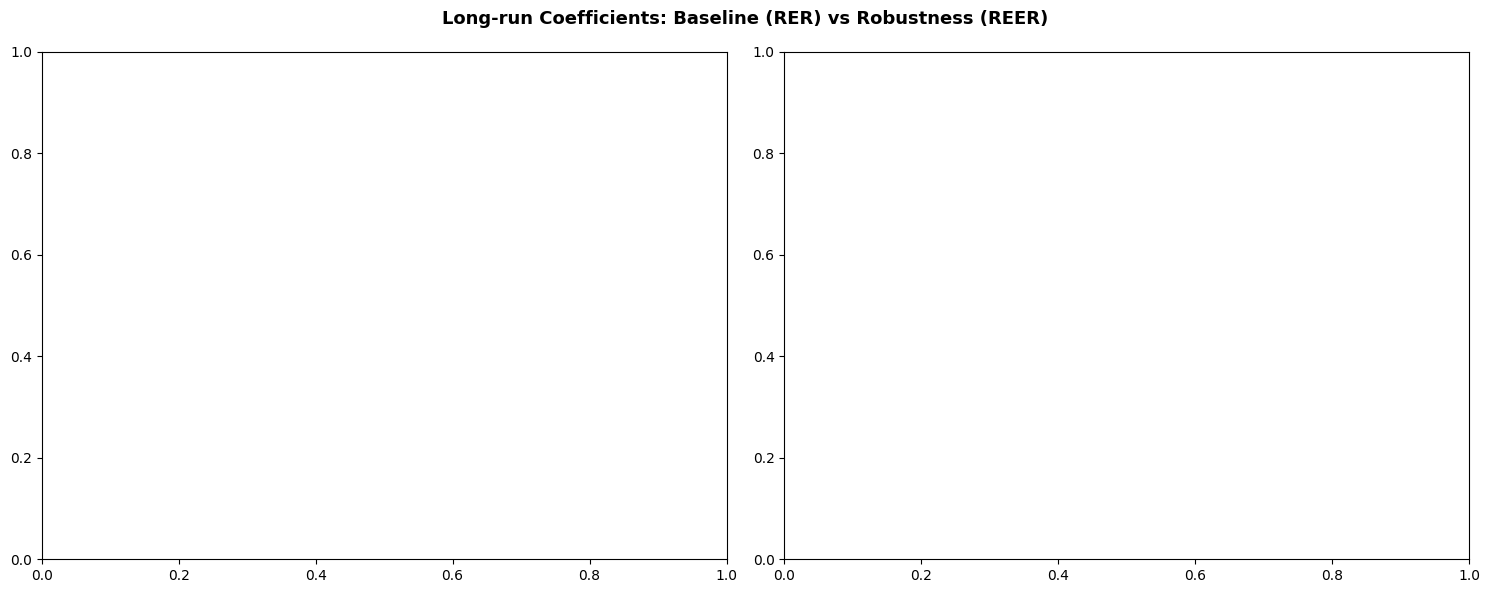

Saved → ../results/robustness\robustness_LR_comparison.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Long-run Coefficients: Baseline (RER) vs Robustness (REER)",
             fontsize=13, fontweight='bold')

colors = {"RER": "#2c7bb6", "REER": "#f46d43"}
w = 0.35

for ax, (base_key, rob_key, dep) in zip(axes, pairs):
    if base_key not in store or rob_key not in store:
        continue

    lr_b = {norm(k): v for k, v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k, v in store[rob_key]['lr'].items()}
    vars_all = sorted(set(lr_b) | set(lr_r))
    x = np.arange(len(vars_all))

    vals_b = [lr_b.get(v, np.nan) for v in vars_all]
    vals_r = [lr_r.get(v, np.nan) for v in vars_all]

    ax.bar(x - w/2, vals_b, width=w, label='Baseline (RER)',
           color=colors["RER"],  alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.bar(x + w/2, vals_r, width=w, label='Robust (REER)',
           color=colors["REER"], alpha=0.85, edgecolor='white', linewidth=0.5)

    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels(vars_all, rotation=38, ha='right', fontsize=8.5)
    ax.set_title(f"dep = {dep}", fontsize=11)
    ax.set_ylabel("Long-run coefficient")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.25)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
fig_path = os.path.join(output_folder, "robustness_LR_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {fig_path}")

## 8. So sánh Short-run: hệ số ExRate_pos & ExRate_neg

In [27]:
# Bảng ngắn tập trung vào biến quan tâm nhất: ExRate pos/neg
print("SHORT-RUN COEFFICIENTS — ExRate (pos & neg)\n")

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        continue
    print(f"  dep = {dep}")
    print(f"  {'Coefficient':40s} {'Baseline(RER)':>14} {'Robust(REER)':>14}")
    print("  " + "-"*70)

    res_b = store[base_key]['res']
    res_r = store[rob_key]['res']

    pos_b = {norm(k): v for k,v in res_b.params.items() if 'RER_pos' in k}
    neg_b = {norm(k): v for k,v in res_b.params.items() if 'RER_neg' in k}
    pos_r = {norm(k): v for k,v in res_r.params.items() if 'REER_pos' in k}
    neg_r = {norm(k): v for k,v in res_r.params.items() if 'REER_neg' in k}

    # Tổng short-run effect
    sum_pos_b = sum(pos_b.values()); sum_neg_b = sum(neg_b.values())
    sum_pos_r = sum(pos_r.values()); sum_neg_r = sum(neg_r.values())

    print(f"  {'Sum SR ExRate_pos':40s} {sum_pos_b:>14.4f} {sum_pos_r:>14.4f}")
    print(f"  {'Sum SR ExRate_neg':40s} {sum_neg_b:>14.4f} {sum_neg_r:>14.4f}")
    print(f"  {'Asymmetry (pos−neg)':40s} {sum_pos_b-sum_neg_b:>14.4f}"
          f" {sum_pos_r-sum_neg_r:>14.4f}")
    print()

SHORT-RUN COEFFICIENTS — ExRate (pos & neg)



## 9. Export tất cả kết quả

In [28]:
summary_rows = []

for key, s in store.items():
    # Short-run
    s['res'].params.to_csv(os.path.join(output_folder, f"{key}_short_run.csv"))
    # Long-run
    if s['lr']:
        pd.Series(s['lr']).to_csv(os.path.join(output_folder, f"{key}_long_run.csv"))
    # ECM + Wald
    pd.DataFrame({
        'ECM(-1)' : [s['ecm']],
        'Wald_F'  : [s['ws']],
        'Wald_p'  : [s['wp']]
    }).to_csv(os.path.join(output_folder, f"{key}_ecm_wald.csv"), index=False)

    summary_rows.append({
        "Model"      : key,
        "Version"    : s['version'],
        "Dep"        : s['dep'],
        "R2"         : round(s['r2'],    4),
        "Adj_R2"     : round(s['adj_r2'],4),
        "AIC"        : round(s['aic'],   1),
        "ECM(-1)"    : round(s['ecm'],   4) if s['ecm']  else None,
        "Wald_F"     : round(s['ws'],    4) if s['ws']   else None,
        "Wald_p"     : round(s['wp'],    4) if s['wp']   else None,
        "Asymmetric" : "Yes" if (s['wp'] and s['wp']<0.05) else "No"
    })

df_sum = pd.DataFrame(summary_rows).set_index("Model")
df_sum.to_csv(os.path.join(output_folder, "robustness_summary.csv"))
print("\nROBUSTNESS SUMMARY")
print("="*70)
print(df_sum.to_string())
print(f"\nAll files saved → {output_folder}/")


ROBUSTNESS SUMMARY
       Version    Dep      R2  Adj_R2    AIC  ECM(-1)  Wald_F  Wald_p Asymmetric
Model                                                                           
EX_RER     RER  ln_EX  0.9170  0.8884 -189.1   0.1943  0.6905  0.4082         No
IM_RER     RER  ln_IM  0.9133  0.8931 -200.3   0.3822  0.0349  0.8522         No

All files saved → ../results/robustness/


## 10. Kết luận tự động

In [30]:
print("ROBUSTNESS CONSISTENCY VERDICT")
print("="*65)

for base_key, rob_key, dep in pairs:
    if base_key not in store or rob_key not in store:
        continue

    lr_b = {norm(k): v for k,v in store[base_key]['lr'].items()}
    lr_r = {norm(k): v for k,v in store[rob_key]['lr'].items()}
    common = set(lr_b) & set(lr_r)

    n_same = sum(np.sign(lr_b[v])==np.sign(lr_r[v]) for v in common)
    pct    = n_same / len(common) * 100 if common else 0

    ecm_ok = (store[base_key]['ecm'] is not None and
              store[rob_key]['ecm']  is not None and
              np.sign(store[base_key]['ecm']) == np.sign(store[rob_key]['ecm']))

    wp_b, wp_r = store[base_key]['wp'], store[rob_key]['wp']
    wald_ok = (wp_b is not None and wp_r is not None and
               (wp_b<0.05) == (wp_r<0.05))

    if pct >= 75 and ecm_ok and wald_ok:
        verdict = "✅  ROBUST  – findings bền vững"
    elif pct >= 50:
        verdict = "⚠️   MIXED  – phần lớn nhất quán, cần thảo luận thêm"
    else:
        verdict = "❌  NOT ROBUST – kết quả phụ thuộc vào lựa chọn RER"

    print(f"\n  {dep}:")
    print(f"    Long-run sign consistency : {n_same}/{len(common)} ({pct:.0f}%)")
    print(f"    ECM same direction        : {'Yes ✓' if ecm_ok else 'No ✗'}")
    print(f"    Wald asymmetry consistent : {'Yes ✓' if wald_ok else 'No ✗'}")
    print(f"    ► {verdict}")

print("\n" + "─"*65)
print("Tiêu chí: ≥75% sign + ECM cùng dấu + Wald nhất quán → ROBUST")

ROBUSTNESS CONSISTENCY VERDICT

─────────────────────────────────────────────────────────────────
Tiêu chí: ≥75% sign + ECM cùng dấu + Wald nhất quán → ROBUST
